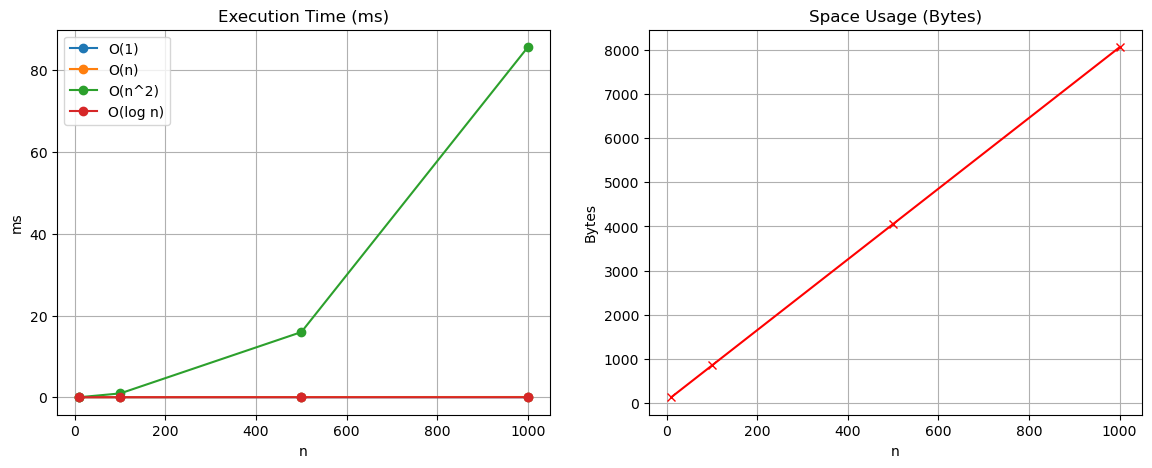

In [3]:
# TASK 1

import timeit
import sys
import matplotlib.pyplot as plt

def constant_time(arr):
    return arr[0] if arr else None

def linear_time(arr):
    total = 0
    for x in arr:
        total += x
    return total

def quadratic_time(arr):
    total = 0
    for i in arr:
        for j in arr:
            total += (i + j)
    return total

def logarithmic_time(arr):
    target = -1
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target: return mid
        elif arr[mid] < target: low = mid + 1
        else: high = mid - 1
    return None

sizes = [10, 100, 500, 1000]
results = {"O(1)": [], "O(n)": [], "O(n^2)": [], "O(log n)": []}
space_usage = []

for n in sizes:
    data = list(range(n))
    space_usage.append(sys.getsizeof(data))
    
    results["O(1)"].append(timeit.timeit(lambda: constant_time(data), number=1000) / 1000 * 1000)
    results["O(n)"].append(timeit.timeit(lambda: linear_time(data), number=1000) / 1000 * 1000)
    results["O(n^2)"].append(timeit.timeit(lambda: quadratic_time(data), number=10) / 10 * 1000)
    results["O(log n)"].append(timeit.timeit(lambda: logarithmic_time(data), number=1000) / 1000 * 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for algo, times in results.items():
    ax1.plot(sizes, times, label=algo, marker='o')
ax1.set_title("Execution Time (ms)")
ax1.set_xlabel("n")
ax1.set_ylabel("ms")
ax1.legend()
ax1.grid(True)

ax2.plot(sizes, space_usage, color='red', marker='x')
ax2.set_title("Space Usage (Bytes)")
ax2.set_xlabel("n")
ax2.set_ylabel("Bytes")
ax2.grid(True)

plt.show()



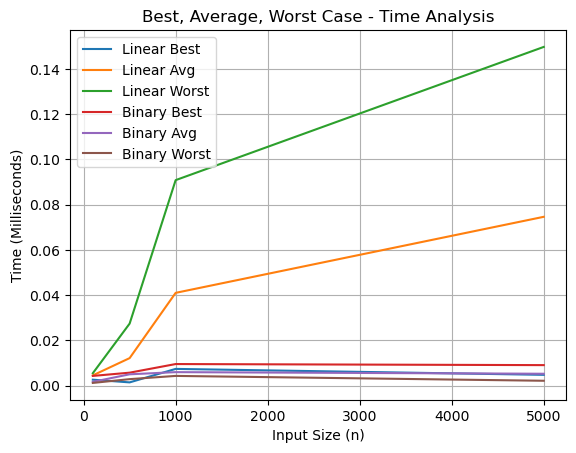

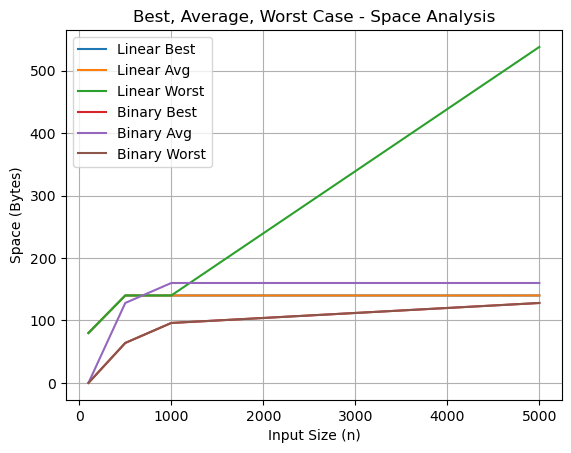

In [5]:
# Task 2: Best, Average, Worst Case Analysis

import random
import time
import tracemalloc
import matplotlib.pyplot as plt

def linear_search(arr, key):
    for i in range(len(arr)):
        if arr[i] == key:
            return i
    return -1

def binary_search(arr, key):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == key:
            return mid
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1
    return -1

def measure_time(func, arr, key):
    start = time.time()
    func(arr, key)
    end = time.time()
    return (end - start) * 1000  

def measure_space(func, arr, key):
    tracemalloc.start()
    func(arr, key)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak  

sizes = [100, 500, 1000, 5000]

lin_best_time, lin_avg_time, lin_worst_time = [], [], []
bin_best_time, bin_avg_time, bin_worst_time = [], [], []

lin_best_space, lin_avg_space, lin_worst_space = [], [], []
bin_best_space, bin_avg_space, bin_worst_space = [], [], []

for n in sizes:
    arr = sorted(random.sample(range(n * 3), n))

    best_key = arr[0]           
    avg_key = arr[n // 2]        
    worst_key = -1              


    lin_best_time.append(measure_time(linear_search, arr, best_key))
    lin_avg_time.append(measure_time(linear_search, arr, avg_key))
    lin_worst_time.append(measure_time(linear_search, arr, worst_key))

    lin_best_space.append(measure_space(linear_search, arr, best_key))
    lin_avg_space.append(measure_space(linear_search, arr, avg_key))
    lin_worst_space.append(measure_space(linear_search, arr, worst_key))

    # Binary Search
    bin_best_time.append(measure_time(binary_search, arr, best_key))
    bin_avg_time.append(measure_time(binary_search, arr, avg_key))
    bin_worst_time.append(measure_time(binary_search, arr, worst_key))

    bin_best_space.append(measure_space(binary_search, arr, best_key))
    bin_avg_space.append(measure_space(binary_search, arr, avg_key))
    bin_worst_space.append(measure_space(binary_search, arr, worst_key))

plt.figure()
plt.plot(sizes, lin_best_time)
plt.plot(sizes, lin_avg_time)
plt.plot(sizes, lin_worst_time)
plt.plot(sizes, bin_best_time)
plt.plot(sizes, bin_avg_time)
plt.plot(sizes, bin_worst_time)

plt.xlabel("Input Size (n)")
plt.ylabel("Time (Milliseconds)")
plt.title("Best, Average, Worst Case - Time Analysis")
plt.legend(["Linear Best", "Linear Avg", "Linear Worst",
            "Binary Best", "Binary Avg", "Binary Worst"])
plt.grid(True)
plt.show()

plt.figure()
plt.plot(sizes, lin_best_space)
plt.plot(sizes, lin_avg_space)
plt.plot(sizes, lin_worst_space)
plt.plot(sizes, bin_best_space)
plt.plot(sizes, bin_avg_space)
plt.plot(sizes, bin_worst_space)

plt.xlabel("Input Size (n)")
plt.ylabel("Space (Bytes)")
plt.title("Best, Average, Worst Case - Space Analysis")
plt.legend(["Linear Best", "Linear Avg", "Linear Worst",
            "Binary Best", "Binary Avg", "Binary Worst"])
plt.grid(True)
plt.show()



n | Fact Time(ms) | Fact Calls | FibNaive Time(ms) | FibNaive Calls | FibDP Time(ms) | FibDP Calls
-----------------------------------------------------------------------------------------------
5 | 0.0055 | 5 | 0.0050 | 15 | 0.0079 | 9
10 | 0.0033 | 10 | 0.0303 | 177 | 0.0081 | 19
15 | 0.0062 | 15 | 0.3405 | 1973 | 0.0148 | 29
20 | 0.0055 | 20 | 9.2187 | 21891 | 0.0165 | 39


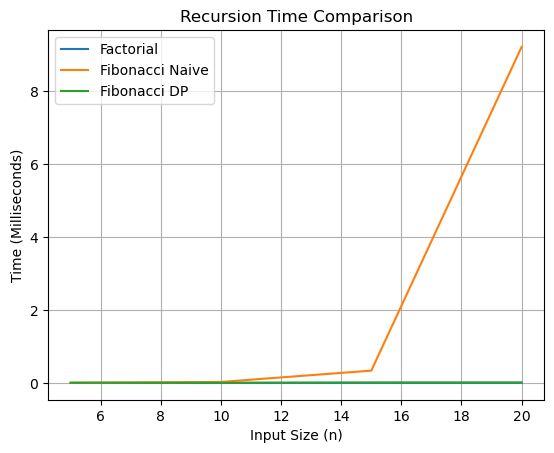

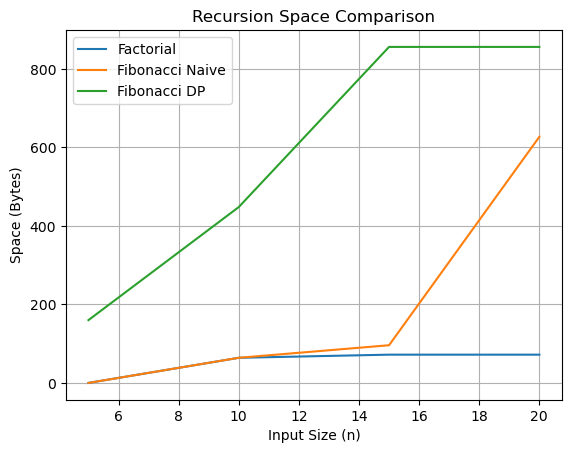

In [6]:
# TASK 3

import time
import tracemalloc
import matplotlib.pyplot as plt

fact_calls = 0
fib_naive_calls = 0
fib_dp_calls = 0

def factorial(n):
    global fact_calls
    fact_calls += 1
    if n <= 1:
        return 1
    return n * factorial(n - 1)

def fibonacci_naive(n):
    global fib_naive_calls
    fib_naive_calls += 1
    if n <= 1:
        return n
    return fibonacci_naive(n - 1) + fibonacci_naive(n - 2)

def fibonacci_dp(n, memo=None):
    global fib_dp_calls
    fib_dp_calls += 1
    if memo is None:
        memo = {}
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fibonacci_dp(n - 1, memo) + fibonacci_dp(n - 2, memo)
    return memo[n]

def measure_time(func, n):
    start = time.time()
    func(n)
    end = time.time()
    return (end - start) * 1000

def measure_space(func, n):
    tracemalloc.start()
    func(n)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

sizes = [5, 10, 15, 20]

fact_time = []
fib_naive_time = []
fib_dp_time = []

fact_space = []
fib_naive_space = []
fib_dp_space = []

print("n | Fact Time(ms) | Fact Calls | FibNaive Time(ms) | FibNaive Calls | FibDP Time(ms) | FibDP Calls")
print("-" * 95)

for n in sizes:
    fact_calls = 0
    fib_naive_calls = 0
    fib_dp_calls = 0

    ft = measure_time(factorial, n)
    fc = fact_calls
    fs = measure_space(factorial, n)

    fib_naive_calls = 0
    fnt = measure_time(fibonacci_naive, n)
    fnc = fib_naive_calls
    fns = measure_space(fibonacci_naive, n)

    fib_dp_calls = 0
    fdt = measure_time(lambda x: fibonacci_dp(x), n)
    fdc = fib_dp_calls
    fds = measure_space(lambda x: fibonacci_dp(x), n)

    fact_time.append(ft)
    fib_naive_time.append(fnt)
    fib_dp_time.append(fdt)

    fact_space.append(fs)
    fib_naive_space.append(fns)
    fib_dp_space.append(fds)

    print(f"{n} | {ft:.4f} | {fc} | {fnt:.4f} | {fnc} | {fdt:.4f} | {fdc}")

plt.figure()
plt.plot(sizes, fact_time)
plt.plot(sizes, fib_naive_time)
plt.plot(sizes, fib_dp_time)
plt.xlabel("Input Size (n)")
plt.ylabel("Time (Milliseconds)")
plt.title("Recursion Time Comparison")
plt.legend(["Factorial", "Fibonacci Naive", "Fibonacci DP"])
plt.grid(True)
plt.show()

plt.figure()
plt.plot(sizes, fact_space)
plt.plot(sizes, fib_naive_space)
plt.plot(sizes, fib_dp_space)
plt.xlabel("Input Size (n)")
plt.ylabel("Space (Bytes)")
plt.title("Recursion Space Comparison")
plt.legend(["Factorial", "Fibonacci Naive", "Fibonacci DP"])
plt.grid(True)
plt.show()




Comparison Table
------------------------------------------------------------
n | T1 Calls | T1 Time(ms) | T2 Calls | T2 Time(ms)
------------------------------------------------------------
8 | 4 | 0.004400 | 15 | 0.005000
16 | 5 | 0.001200 | 31 | 0.005600
32 | 6 | 0.001300 | 63 | 0.011300
64 | 7 | 0.001300 | 127 | 0.021800
128 | 8 | 0.001900 | 255 | 0.043000


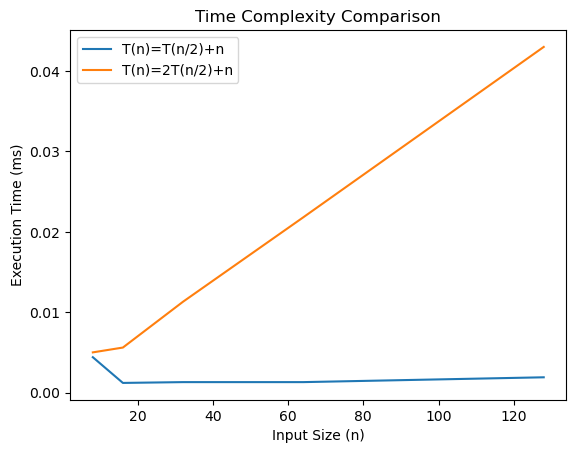

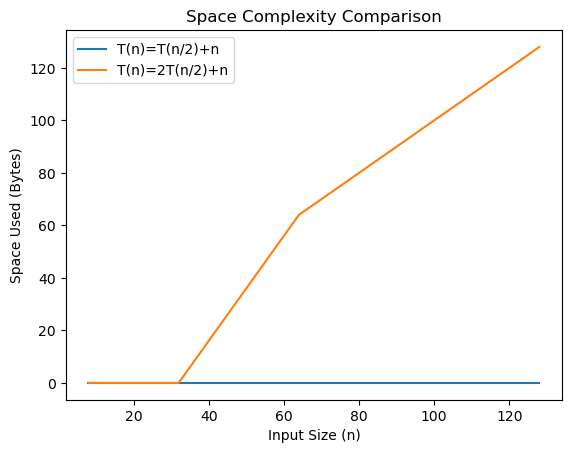

In [8]:
# TASK 4
import time
import tracemalloc
import matplotlib.pyplot as plt

calls_T1 = 0
calls_T2 = 0

def T1(n):
    global calls_T1
    calls_T1 += 1
    if n <= 1:
        return 1
    return T1(n // 2) + n

def T2(n):
    global calls_T2
    calls_T2 += 1
    if n <= 1:
        return 1
    return T2(n // 2) + T2(n // 2) + n

def measure_time(func, n):
    start = time.perf_counter()
    func(n)
    end = time.perf_counter()
    return (end - start) * 1000

def measure_space(func, n):
    tracemalloc.start()
    func(n)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

inputs = [8, 16, 32, 64, 128]

T1_time, T2_time = [], []
T1_space, T2_space = [], []

print("\nComparison Table")
print("-" * 60)
print("n | T1 Calls | T1 Time(ms) | T2 Calls | T2 Time(ms)")
print("-" * 60)

for n in inputs:
    calls_T1 = 0
    t1_time = measure_time(T1, n)
    t1_calls = calls_T1
    t1_space = measure_space(T1, n)

    calls_T2 = 0
    t2_time = measure_time(T2, n)
    t2_calls = calls_T2
    t2_space = measure_space(T2, n)

    T1_time.append(t1_time)
    T2_time.append(t2_time)

    T1_space.append(t1_space)
    T2_space.append(t2_space)

    print(f"{n} | {t1_calls} | {t1_time:.6f} | {t2_calls} | {t2_time:.6f}")

plt.figure()
plt.plot(inputs, T1_time, label="T(n)=T(n/2)+n")
plt.plot(inputs, T2_time, label="T(n)=2T(n/2)+n")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (ms)")
plt.title("Time Complexity Comparison")
plt.legend()
plt.show()

plt.figure()
plt.plot(inputs, T1_space, label="T(n)=T(n/2)+n")
plt.plot(inputs, T2_space, label="T(n)=2T(n/2)+n")
plt.xlabel("Input Size (n)")
plt.ylabel("Space Used (Bytes)")
plt.title("Space Complexity Comparison")
plt.legend()
plt.show()

